# Day 50 - Optimizers & scheduling
- Gradient Descent recap
- Momentum Optimization
- Nesterov Accelerated Gradient (NAG)
- AdaGrad
- RMSProp
- Adam
- Nadam
- Power scheduling
- Exponential scheduling
- Piecewise constant scheduling
- Performance scheduling / ReduceLROnPlateau

## 1. Why do we need faster optimizers?

Basic Gradient Descent updates parameters using:

\[
\theta_{t+1}=\theta_t-\eta\nabla_\theta J(\theta_t)
\]

where:
- `θ` = model parameters
- `J(θ)` = loss
- `∇J(θ)` = gradient
- `η` = learning rate

The learning rate controls the size of each update.

**Too small:** training is slow.

**Too large:** training can oscillate or diverge.

Deep neural networks often have complicated loss surfaces, so better optimization methods can substantially improve training speed and stability.

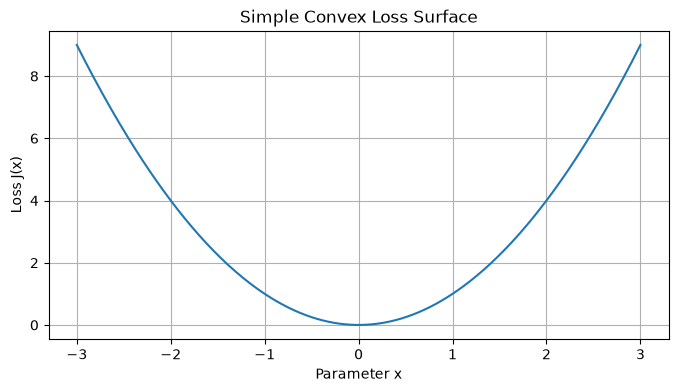

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A simple 1D quadratic loss to visualize the effect of step size.
def loss(x):
    return x**2

x = np.linspace(-3, 3, 400)
plt.figure(figsize=(8, 4))
plt.plot(x, loss(x))
plt.xlabel("Parameter x")
plt.ylabel("Loss J(x)")
plt.title("Simple Convex Loss Surface")
plt.grid(True)
plt.show()

## 2. Momentum Optimization

Momentum keeps a running velocity based on previous gradients.

Conceptually:

\[
m \leftarrow \beta m-\eta\nabla_\theta J(\theta)
\]

\[
\theta \leftarrow \theta+m
\]

A common value is `β = 0.9`.

### Intuition

Instead of asking only:

> "Which direction does today's gradient tell me to move?"

Momentum also asks:

> "Which direction have recent gradients consistently told me to move?"

This helps accelerate movement along useful directions and reduce oscillation across narrow valleys.

**Memory trick:** Momentum = *remember the direction*.

In [2]:
import tensorflow as tf

# Momentum SGD
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

optimizer

## 3. Nesterov Accelerated Gradient (NAG)

Nesterov improves Momentum by looking ahead before evaluating the gradient.

Ordinary Momentum:
1. Use the current gradient.
2. Move using accumulated velocity.

Nesterov:
1. Look ahead in the direction of momentum.
2. Evaluate the gradient there.
3. Correct the movement.

Conceptually:

\[
m \leftarrow \beta m-\eta\nabla J(\theta+\beta m)
\]

\[
\theta \leftarrow \theta+m
\]

**Memory trick:** Nesterov = *look ahead before deciding the correction*.

In [3]:
# Nesterov Momentum in Keras
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9,
    nesterov=True
)

optimizer

## 4. AdaGrad

AdaGrad stands for **Adaptive Gradient**.

It gives each parameter an adaptive effective learning rate.

It accumulates squared gradients:

\[
s \leftarrow s+\nabla J(\theta)^2
\]

and updates:

\[
\theta \leftarrow
\theta-\eta
\frac{\nabla J(\theta)}
{\sqrt{s+\epsilon}}
\]

If a parameter repeatedly receives large gradients, its effective learning rate becomes smaller.

### Main advantage
Different parameters can learn at different effective rates.

### Major weakness
Because `s` keeps accumulating, it can become very large. The effective learning rate can eventually become extremely small, causing learning to slow or stop.

**Memory trick:** AdaGrad = *accumulate all historical squared gradients*.

In [4]:
# Simple numerical illustration of AdaGrad's accumulating squared gradients.
gradients = np.array([1.0, 0.5, 2.0, 0.25])

s = 0.0
rows = []
for g in gradients:
    s += g**2
    effective_scale = 1 / np.sqrt(s + 1e-8)
    rows.append((g, s, effective_scale))

rows

[(np.float64(1.0), np.float64(1.0), np.float64(0.999999995)),
 (np.float64(0.5), np.float64(1.25), np.float64(0.8944271874222073)),
 (np.float64(2.0), np.float64(5.25), np.float64(0.43643578005633166)),
 (np.float64(0.25), np.float64(5.3125), np.float64(0.43386091522897263))]

## 5. RMSProp

RMSProp addresses AdaGrad's tendency to shrink the learning rate too much.

Instead of accumulating every squared gradient forever, it uses an exponentially weighted average:

\[
s \leftarrow \rho s+(1-\rho)(\nabla J(\theta))^2
\]

Then:

\[
\theta \leftarrow
\theta-\eta
\frac{\nabla J(\theta)}
{\sqrt{s+\epsilon}}
\]

Old gradients gradually lose influence.

### Key difference

**AdaGrad**
\[
s_t=s_{t-1}+g_t^2
\]

**RMSProp**
\[
s_t=\rho s_{t-1}+(1-\rho)g_t^2
\]

**Memory trick:** RMSProp = *AdaGrad with forgetting*.

In [5]:
optimizer = tf.keras.optimizers.RMSprop(
    learning_rate=0.001,
    rho=0.9
)

optimizer

## 6. Adam — Adaptive Moment Estimation

Adam combines ideas from **Momentum** and **RMSProp**.

It keeps:

### First moment
A moving average of gradients:

\[
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
\]

This provides Momentum-like direction information.

### Second moment
A moving average of squared gradients:

\[
s_t=\beta_2s_{t-1}+(1-\beta_2)g_t^2
\]

This provides RMSProp-like scale information.

Because both estimates start at zero, Adam uses bias correction:

\[
\hat m_t=\frac{m_t}{1-\beta_1^t}
\]

\[
\hat s_t=\frac{s_t}{1-\beta_2^t}
\]

Final update:

\[
\theta_t=
\theta_{t-1}
-\eta
\frac{\hat m_t}{\sqrt{\hat s_t}+\epsilon}
\]

**Memory trick:** Adam = *Momentum + RMSProp + bias correction*.

In [6]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

optimizer

## 7. Nadam

Nadam means **Nesterov-accelerated Adaptive Moment Estimation**.

The conceptual combination is:

- Adam → adaptive first and second moments
- Nesterov → look-ahead acceleration

So:

**Nadam = Adam + Nesterov idea**

The practical difference from Adam depends on the problem and tuning.

In [7]:
optimizer = tf.keras.optimizers.Nadam(
    learning_rate=0.001
)

optimizer

## 8. Optimizer family — mental map

```text
Gradient Descent
│
├── Momentum
│    └── Nesterov
│
└── Adaptive methods
     ├── AdaGrad
     └── RMSProp
          └── Adam
               └── Nadam
```

Another useful memory map:

```text
Momentum  → remembers direction
Nesterov  → looks ahead
AdaGrad   → accumulates squared gradients
RMSProp   → exponentially forgets old squared gradients
Adam      → Momentum + RMSProp
Nadam     → Adam + Nesterov
```

## 9. Learning-rate scheduling

The learning rate does not have to remain constant.

Instead:

\[
\eta=\eta(t)
\]

The general intuition is:

```text
Beginning: relatively large steps
        ↓
Explore the loss surface
        ↓
Later: smaller steps
        ↓
Fine-tune near a solution
```

Learning-rate scheduling is separate from the optimizer.

For example:

```text
Adam + exponential decay
SGD + momentum + 1cycle
RMSProp + performance scheduling
```

## 10. Power scheduling

A common power-decay form is:

\[
\eta(s)=\frac{\eta_0}{(1+s/r)^c}
\]

where:
- `η₀` = initial learning rate
- `s` = training step
- `r` = decay parameter
- `c` = power

For `c = 1`:

\[
\eta(s)=\frac{\eta_0}{1+s/r}
\]

The learning rate gradually decreases as training progresses.

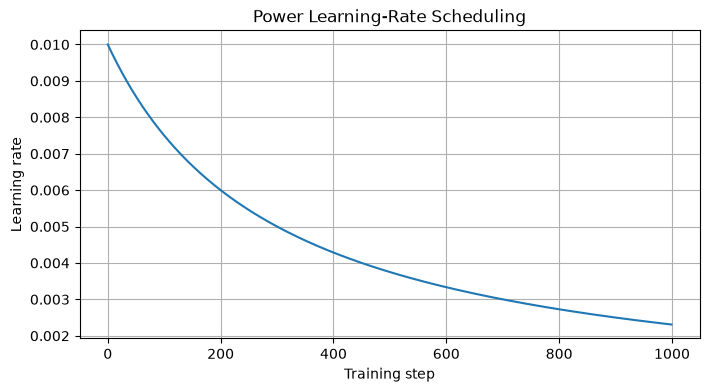

In [8]:
# Visualize power scheduling
steps = np.arange(0, 1000)
eta0 = 0.01
r = 300
c = 1

lr_power = eta0 / (1 + steps / r)**c

plt.figure(figsize=(8, 4))
plt.plot(steps, lr_power)
plt.xlabel("Training step")
plt.ylabel("Learning rate")
plt.title("Power Learning-Rate Scheduling")
plt.grid(True)
plt.show()

## 11. Exponential scheduling

Exponential scheduling decreases the learning rate exponentially.

A common form is:

\[
\eta(s)=\eta_0(0.1)^{s/r}
\]

The learning rate falls smoothly and continuously.

Compared with power decay, exponential decay can become small more quickly depending on the chosen parameters.

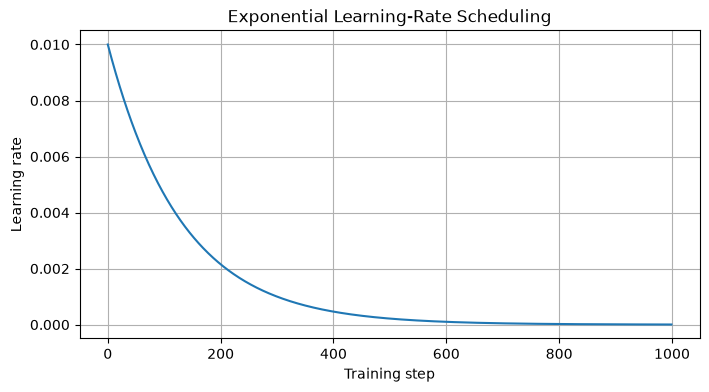

In [9]:
# Visualize exponential scheduling
lr_exp = eta0 * (0.1 ** (steps / r))

plt.figure(figsize=(8, 4))
plt.plot(steps, lr_exp)
plt.xlabel("Training step")
plt.ylabel("Learning rate")
plt.title("Exponential Learning-Rate Scheduling")
plt.grid(True)
plt.show()

## 12. Piecewise constant scheduling

Here the learning rate changes at predefined boundaries.

Example:

```text
Epoch 0–10    → 0.01
Epoch 11–20   → 0.005
Epoch 21–30   → 0.001
Epoch 31+     → 0.0005
```

Advantages:
- Easy to understand
- Easy to control
- Useful when you already know reasonable transition points

Disadvantage:
- Changes can be abrupt.

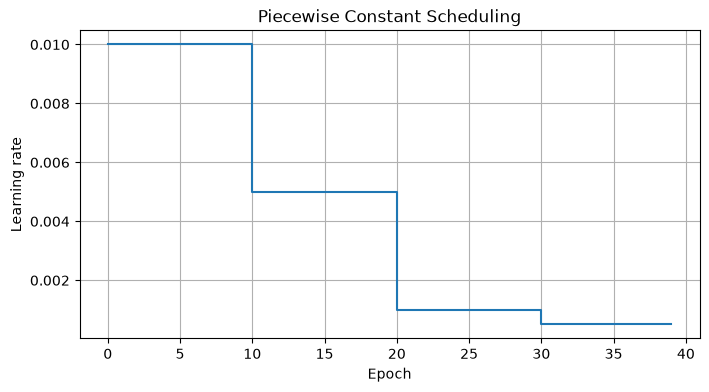

In [10]:
# Example piecewise constant schedule
boundaries = [10, 20, 30]
values = [0.01, 0.005, 0.001, 0.0005]

def piecewise_lr(epoch):
    if epoch < boundaries[0]:
        return values[0]
    elif epoch < boundaries[1]:
        return values[1]
    elif epoch < boundaries[2]:
        return values[2]
    return values[3]

epochs = np.arange(0, 40)
piecewise_values = [piecewise_lr(e) for e in epochs]

plt.figure(figsize=(8, 4))
plt.step(epochs, piecewise_values, where="post")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Piecewise Constant Scheduling")
plt.grid(True)
plt.show()

## 13. Performance scheduling

Performance scheduling changes the learning rate based on a monitored metric rather than a fixed epoch schedule.

Typical pattern:

```text
Validation loss improves
        ↓
Keep training

Validation loss stops improving
        ↓
Wait for patience period
        ↓
Reduce learning rate
        ↓
Continue training
```

In Keras this is commonly implemented using `ReduceLROnPlateau`.

This is useful when you do not know in advance exactly when the model will plateau.

In [11]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

reduce_lr

## 14. 1cycle learning

The 1cycle idea uses one learning-rate cycle during training.

A simplified shape is:

```text
Learning rate

       /\
      /  \
     /    \
____/      \____
```

The learning rate:
1. Starts relatively low.
2. Increases to a higher value.
3. Decreases again, often to a very low value.

Momentum is generally varied inversely:

```text
Learning rate:  LOW → HIGH → LOW
Momentum:       HIGH → LOW → HIGH
```

The intuition is:

**Explore with a larger learning rate, then fine-tune with a smaller one.**

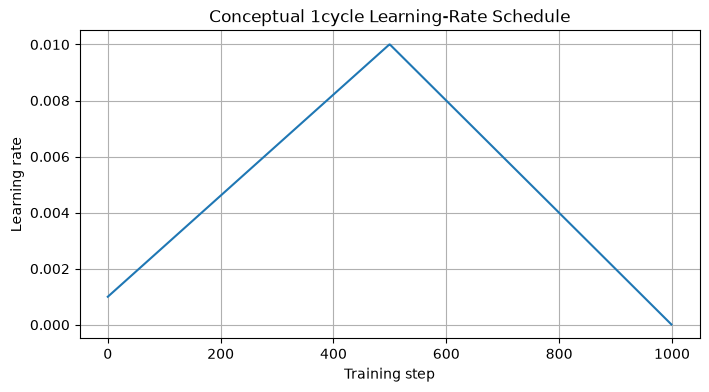

In [12]:
# Simple conceptual 1cycle learning-rate curve
total_steps = 1000
half = total_steps // 2
max_lr = 0.01
start_lr = 0.001
final_lr = 0.00001

up = np.linspace(start_lr, max_lr, half)
down = np.linspace(max_lr, final_lr, total_steps - half)
lr_1cycle = np.concatenate([up, down])

plt.figure(figsize=(8, 4))
plt.plot(np.arange(total_steps), lr_1cycle)
plt.xlabel("Training step")
plt.ylabel("Learning rate")
plt.title("Conceptual 1cycle Learning-Rate Schedule")
plt.grid(True)
plt.show()

## 15. Optimizer vs learning-rate scheduler

This distinction is important.

### Optimizer
Controls **how parameters are updated**.

Examples:
- SGD
- Momentum SGD
- RMSProp
- Adam
- Nadam

### Scheduler
Controls **how the learning rate changes over time**.

Examples:
- Power decay
- Exponential decay
- Piecewise constant
- Performance-based reduction
- 1cycle

They can be combined.

## 16. TensorFlow/Keras — exponential decay + Adam

A schedule can be passed directly to an optimizer.

```python
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=10000,
    decay_rate=0.1
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule
)
```

The optimizer then receives a learning rate that changes as training progresses.

In [13]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=10_000,
    decay_rate=0.1
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule
)

optimizer

## 17. Complete Keras training example

The following example combines:
- A simple regression dataset
- A neural network
- Adam
- Exponential learning-rate decay
- Validation monitoring

It is intentionally small enough to run on a CPU.

In [14]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_regression(
    n_samples=5000,
    n_features=10,
    noise=15,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.5
)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule
)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 7881.2588 - mae: 52.8817 - val_loss: 438.3394 - val_mae: 16.4386
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 352.7588 - mae: 14.8661 - val_loss: 326.0774 - val_mae: 14.1864
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 279.3003 - mae: 13.3572 - val_loss: 291.9804 - val_mae: 13.7310
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 255.9142 - mae: 12.7877 - val_loss: 273.4575 - val_mae: 12.9894
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 243.8614 - mae: 12.4185 - val_loss: 245.0497 - val_mae: 12.4675
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 235.4983 - mae: 12.2598 - val_loss: 247.7536 - val_mae: 12.6096
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 236.6601 - mae: 12.2465 - val_loss: 252.7930 - val_mae: 12.7418
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 231.7068 - mae: 12.0955 - val_loss: 244.3386 - val_mae: 12.5548
Epoch 9

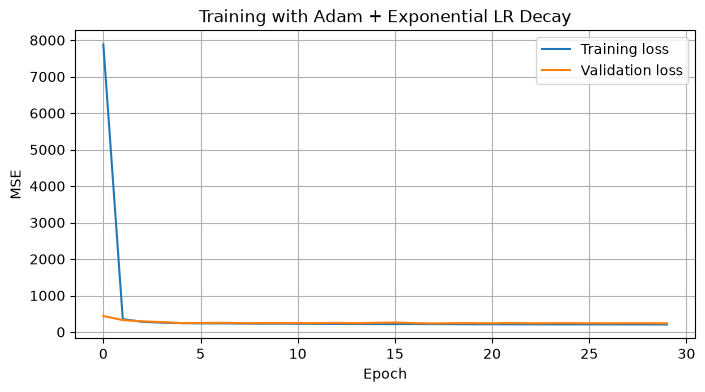

In [15]:
# Plot training and validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training with Adam + Exponential LR Decay")
plt.legend()
plt.grid(True)
plt.show()

## 18. Compare common optimizers

A useful learning exercise is to train the same architecture with different optimizers.

Important rule:

> When comparing optimizers, keep the dataset, architecture, batch size, number of epochs, and evaluation procedure consistent.

Otherwise you are not making a clean comparison.

In [16]:
def build_regression_model(optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )
    return model

optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=0.01, momentum=0.9
    ),
    "RMSProp": tf.keras.optimizers.RMSprop(
        learning_rate=0.001
    ),
    "Adam": tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    "Nadam": tf.keras.optimizers.Nadam(
        learning_rate=0.001
    )
}

results = {}

for name, opt in optimizers.items():
    tf.keras.backend.clear_session()
    model = build_regression_model(opt)
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_valid, y_valid),
        epochs=15,
        batch_size=32,
        verbose=0
    )
    results[name] = history.history

print("Finished:", list(results.keys()))


Finished: ['SGD', 'Momentum', 'RMSProp', 'Adam', 'Nadam']


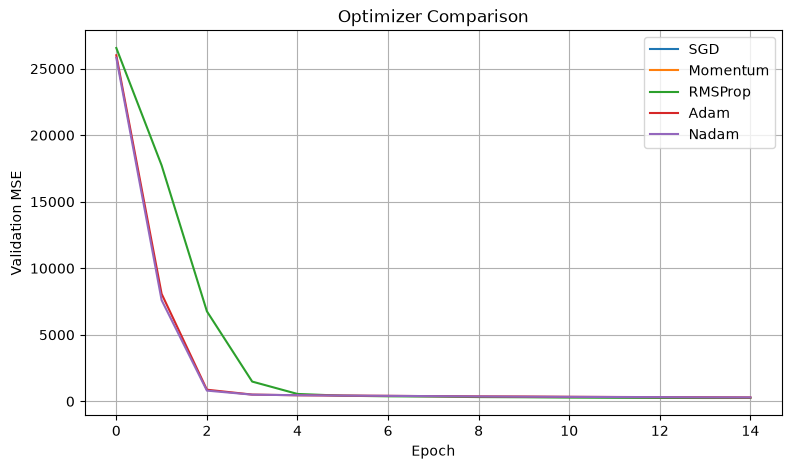

In [17]:
plt.figure(figsize=(9, 5))

for name, history_dict in results.items():
    plt.plot(history_dict["val_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid(True)
plt.show()

## Practical mental model

```text
                 Faster training
                       │
        ┌──────────────┴──────────────┐
        │                             │
   Better optimizer             Better LR control
        │                             │
  ┌─────┼───────────┐         ┌───────┼─────────┐
  │     │           │         │       │         │
Momentum Adaptive   Adam    Power  Exponential Performance
  │     methods       │      │       │         │
  │       │           │      └───────┴─────────┘
Nesterov  │         Nadam
          │
       AdaGrad
          │
       RMSProp
```

The fundamental goal is:

> **Take useful steps quickly early in training, then make smaller, more controlled updates as the model approaches a good solution.**

### Optimizers

**Momentum**
> Remember direction.

**Nesterov**
> Look ahead.

**AdaGrad**
> Accumulate squared gradients.

**RMSProp**
> Exponentially forget old squared gradients.

**Adam**
> Momentum + RMSProp + bias correction.

**Nadam**
> Adam + Nesterov.

### Scheduling

**Power**
> Learning rate decreases according to a power function.

**Exponential**
> Learning rate decreases exponentially.

**Piecewise**
> Learning rate changes at predefined boundaries.

**Performance**
> Learning rate changes when validation performance plateaus.

**1cycle**
> Learning rate rises, then falls; momentum generally moves inversely.

### One-line memory trick

> **Momentum remembers direction → Nesterov looks ahead → AdaGrad remembers all gradient magnitudes → RMSProp forgets old magnitudes → Adam combines direction + magnitude → Nadam adds look-ahead → scheduling changes the learning rate over time → 1cycle goes up then down.**